#### Import e Configurazione

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

In [11]:

# --- CONFIGURAZIONE ---
CSV_PATH = '../data/processed/metadata/all_processed.csv'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Cartella per salvare i modelli
OUTPUT_DIR = '../experiments/exp20260608_baseline_resnet50_fine_tuned/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)

#### Preparazione Dati e Pipeline

Filtriamo il dataset per usare solo i dati reali di train e validation. Includiamo la funzione aggiornata con l'aggiunta del rumore gaussiano per la data augmentation.

In [12]:
# 1. Carica e filtra il CSV
df = pd.read_csv(CSV_PATH)
df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val = df[df['split'] == 'val'].reset_index(drop=True)

# 2. Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

# 3. Funzioni tf.data (con rumore gaussiano per augmentation)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    
    if augment:
        # Aggiunta di rumore gaussiano leggero
        noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.05, dtype=tf.float32)
        img = img + noise
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
        
    return img, tf.cast(label, tf.float32)

def make_dataset(df, augment=False, shuffle=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l, augment=augment), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, augment=True, shuffle=True)
val_ds = make_dataset(df_val, augment=False, shuffle=False)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/metadata/all_processed.csv'

#### Costruzione dell'Architettura ResNet-50

Creiamo la funzione che istanzia il modello. Inizialmente, congeliamo tutto il backbone (ResNet-50) per addestrare solo la nostra testina di classificazione (custom head).

In [ ]:
def build_base_model():
    # Carica il backbone ResNet-50 pre-addestrato
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    # Congela il backbone per la Fase 1
    base_model.trainable = False
    
    # Costruisci l'architettura completa
    inputs = keras.Input(shape=(224, 224, 3))
    
    # training=False è fondamentale qui per la Batch Normalization
    x = base_model(inputs, training=False) 
    
    # Global Average Pooling (scelta ottimale per ridurre i parametri)
    x = layers.GlobalAveragePooling2D()(x)
    
    # Custom Head con LeakyReLU
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.1)(x) # alpha è la pendenza per i valori negativi
    x = layers.Dropout(0.5)(x)
    
    # Output binario (1 neurone con sigmoid)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_base_model()
model.summary()

/home/enzo/tf-gpu/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Fase 1: Addestramento Custom Head

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall')
    ]
)

callbacks_fase1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'baseline_fase1_best.keras'), monitor='val_auc', save_best_only=True, mode='max')
]

history_phase1 = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase1
)

Epoch 1/15


I0000 00:00:1780931135.045100   15725 service.cc:153] XLA service 0x78d3c8068b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780931135.045169   15725 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1780931135.767618   15725 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780931139.021683   15725 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1780931139.231503   15725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14175__.187
I0000 00:00:1780931150.413614   15725 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5349 - auc: 0.5016 - loss: 0.7981 - recall: 0.4990

I0000 00:00:1780931156.840325   15724 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14175__.187


64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 515ms/step - accuracy: 0.5213 - auc: 0.5343 - loss: 0.7916 - recall: 0.5647 - val_accuracy: 0.2860 - val_auc: 0.6008 - val_loss: 0.8133 - val_recall: 0.9041
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.5473 - auc: 0.5563 - loss: 0.7138 - recall: 0.5000 - val_accuracy: 0.6110 - val_auc: 0.6147 - val_loss: 0.6630 - val_recall: 0.5205
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.5870 - auc: 0.5927 - loss: 0.6896 - recall: 0.5441 - val_accuracy: 0.7346 - val_auc: 0.6308 - val_loss: 0.6177 - val_recall: 0.3562
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.5811 - auc: 0.5962 - loss: 0.6827 - recall: 0.5412 - val_accuracy: 0.3959 - val_auc: 0.6146 - val_loss: 0.7621 - val_recall: 0.8493
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.5247 - auc: 0.5910 - loss: 0.6920 - recall: 0.5971 - val_accuracy: 0.3959 - val_auc: 0.6191 - val_loss: 0.7368 - val_recall: 0.8630
Epoch 6/15
64/64 ━━━━━

#### Fase 2: Fine Tuning

In [ ]:
# Scongela l'intero modello base
base_model.trainable = True

# Ricongela i layer inferiori, lasciando allenabili solo gli ultimi 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Ricontrolla i layer allenabili
print(f"Totale layer nel base_model: {len(base_model.layers)}")
print(f"Layer allenabili: {len(model.trainable_variables)}")

# Ricompila il modello con un Learning Rate MOLTO basso (fondamentale!)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall')
    ]
)



callbacks_fase2 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'baseline_final_best.keras'), monitor='val_auc', save_best_only=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,  # Più epoche, ma interverrà l'EarlyStopping
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {OUTPUT_DIR}baseline_final_best.keras")

Totale layer nel base_model: 175
Layer allenabili: 40
Epoch 1/30


I0000 00:00:1780931353.575910   15723 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48263__.223


63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8397 - auc: 0.5072 - loss: 10.2400 - recall: 0.0048

I0000 00:00:1780931373.480868   15722 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48263__.223


64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 515ms/step - accuracy: 0.8300 - auc: 0.5329 - loss: 7.8550 - recall: 0.0324 - val_accuracy: 0.3936 - val_auc: 0.5775 - val_loss: 2.2336 - val_recall: 0.7945 - learning_rate: 1.0000e-05
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.7109 - auc: 0.6962 - loss: 1.3037 - recall: 0.5353 - val_accuracy: 0.4462 - val_auc: 0.6048 - val_loss: 1.5970 - val_recall: 0.7808 - learning_rate: 1.0000e-05
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.7349 - auc: 0.8012 - loss: 0.6425 - recall: 0.7206 - val_accuracy: 0.5126 - val_auc: 0.6115 - val_loss: 1.1368 - val_recall: 0.6575 - learning_rate: 1.0000e-05
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.7589 - auc: 0.8415 - loss: 0.5460 - recall: 0.7471 - val_accuracy: 0.6224 - val_auc: 0.6009 - val_loss: 0.8721 - val_recall: 0.5205 - learning_rate: 1.0000e-05
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.8192 - auc: 0.8990 - loss: 0.4129 - rec

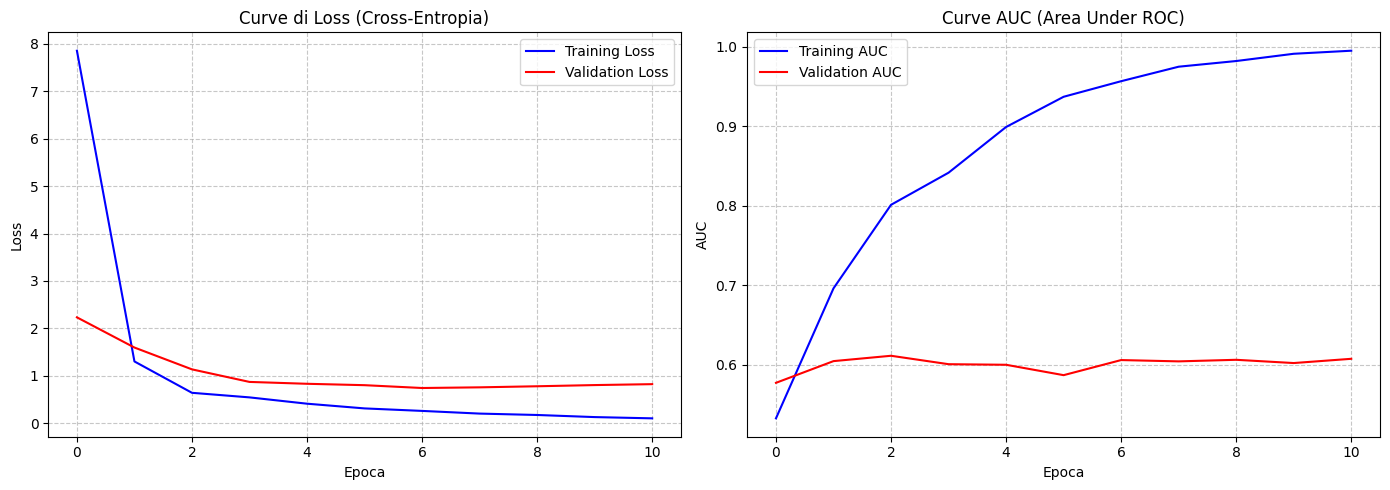

In [ ]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafico della Loss (Ricerca la divergenza)
    ax1.plot(history.history['loss'], label='Training Loss', color='blue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Curve di Loss (Cross-Entropia)')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Grafico dell'AUC (Ricerca il divario)
    ax2.plot(history.history['auc'], label='Training AUC', color='blue')
    ax2.plot(history.history['val_auc'], label='Validation AUC', color='red')
    ax2.set_title('Curve AUC (Area Under ROC)')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Utilizzo:
plot_training_history(history_phase2)

---
## Config `trad_aug`: ResNet-50 su reali + **augmentation tradizionale** (+ valutazione, tool di Samuele)

Stessa architettura ResNet-50 del baseline, addestrata sulla config **originali + augmentati
tradizionali** (il compito di Samuele per la D3):
- **TRAIN** = originali reali a 2 classi (`data/processed/train/{0,1}`) **+** positivi augmentati
  in modo tradizionale (`data/real_augmented`, solo `_label1`, suffisso `_augN`).
- **VAL / TEST** = solo reali held-out (`data/processed/{val,test}`), mai augmentati.

Al termine: predizioni sul **test reale** → `ClassifierEvaluator` (metriche + confusion matrix +
valutazione bilanciata a bootstrap, dato che il test è ~5:1) e sostenibilità di training/inferenza
via `eco_tracker`. La consegna a Samuele avviene con `io_contratto.consegna_classificatore`
(scrive in `consegne/` nel formato che la pipeline si aspetta).

> **Percorsi**: relativi a un notebook un livello sotto `MammoDiffusion/` (`../data/...`).
> **Prerequisiti**: eseguire prima le celle *Configurazione* e *Architettura* (`build_base_model`).
> Richiede TensorFlow. L'augmentation tradizionale è già materializzata in `real_augmented`,
> quindi `AUG_ONLINE = False` di default (niente doppia augmentation); mettere `True` per abilitarla.

In [ ]:
import re
from pathlib import Path
import numpy as np
import tensorflow as tf

# === Config locale (rispecchia la cella di Configurazione del baseline: questa sezione
# e' autonoma e gira anche se quella cella non e' stata eseguita) ===
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

# === Percorsi (notebook un livello sotto MammoDiffusion/) ===
DIR_TRAIN = Path("../data/processed/train")   # originali: sottocartelle 0/ (Sano) e 1/ (Malato)
DIR_VAL   = Path("../data/processed/val")
DIR_TEST  = Path("../data/processed/test")
DIR_AUG   = Path("../data/real_augmented")    # augmentati TRADIZIONALI, solo positivi (label nel nome)

# Config trad_aug: TRAIN = originali (2 classi) + augmentati positivi ;
#                  VAL/TEST = SOLO reali held-out (mai augmentati).
# L'augmentation tradizionale e' gia' materializzata in real_augmented -> niente aug on-the-fly di default.
AUG_ONLINE = False   # True per aggiungere anche rumore/brightness/contrast a runtime

_LABEL_RE = re.compile(r"_label([01])")

def carica_da_cartelle_classi(base_dir, classi=("0", "1")):
    """Originali: la label e' il nome della sottocartella (0=Sano, 1=Malato)."""
    paths, labels = [], []
    for c in classi:
        for p in sorted((Path(base_dir) / c).glob("*.png")):
            paths.append(str(p)); labels.append(int(c))
    return np.array(paths), np.array(labels, dtype=np.int32)

def carica_da_nome(dirpath):
    """Augmentati: la label e' nel nome file (_label0 / _label1)."""
    paths, labels = [], []
    for p in sorted(Path(dirpath).glob("*.png")):
        m = _LABEL_RE.search(p.name)
        if m is None:
            print(f"[skip] nessuna label nel nome: {p.name}"); continue
        paths.append(str(p)); labels.append(int(m.group(1)))
    return np.array(paths), np.array(labels, dtype=np.int32)

# --- TRAIN = originali reali (2 classi) + augmentati positivi ---
real_tr_p, real_tr_y = carica_da_cartelle_classi(DIR_TRAIN)
aug_p,     aug_y     = carica_da_nome(DIR_AUG)
train_p_trad = np.concatenate([real_tr_p, aug_p])
train_y_trad = np.concatenate([real_tr_y, aug_y])

# --- VAL / TEST = SOLO reali held-out ---
val_p_trad,  val_y_trad  = carica_da_cartelle_classi(DIR_VAL)
test_p_trad, test_y_trad = carica_da_cartelle_classi(DIR_TEST)

def _comp(nome, y):
    print(f"{nome:6s} tot={len(y):5d} | Sano(0)={int((y==0).sum()):5d} | Malato(1)={int((y==1).sum()):5d}")
print(f"[trad_aug] reali train={len(real_tr_y)} + augmentati positivi={len(aug_y)}")
_comp("TRAIN", train_y_trad); _comp("VAL", val_y_trad); _comp("TEST", test_y_trad)

# --- Pipeline tf.data (grayscale->3ch, resize IMG_SIZE, normalizzazione ImageNet) ---
def _preprocess(path, label, augment):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    if augment:
        img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=0.05, dtype=tf.float32)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, tf.cast(label, tf.float32)

def make_ds(p, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if shuffle:
        ds = ds.shuffle(len(p), seed=SEED)
    ds = ds.map(lambda a, b: _preprocess(a, b, augment), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds_trad = make_ds(train_p_trad, train_y_trad, augment=AUG_ONLINE, shuffle=True)
val_ds_trad   = make_ds(val_p_trad,   val_y_trad,   augment=False,      shuffle=False)
test_ds_trad  = make_ds(test_p_trad,  test_y_trad,  augment=False,      shuffle=False)

In [ ]:
from eco_tracker import measure_sustainability
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow import keras

# Stessa architettura del baseline (riusa build_base_model definita sopra)
model_trad, base_model_trad = build_base_model()
model_trad.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall")],
)

# Pesi delle classi dal train trad_aug (anche con gli augmentati i positivi restano meno numerosi)
_classes = np.unique(train_y_trad)
_w = compute_class_weight("balanced", classes=_classes, y=train_y_trad)
class_weight_trad = dict(zip(_classes.astype(int), _w))
print("Class weights:", class_weight_trad)

# --- Training completo misurato per eco_tracker (Fase 1 testina + Fase 2 fine-tuning) ---
with measure_sustainability(label="training_trad_aug") as eco:
    # Fase 1: addestra solo la testina (backbone congelato)
    model_trad.fit(train_ds_trad, epochs=10,
                   validation_data=val_ds_trad, class_weight=class_weight_trad)

    # Fase 2: fine-tuning degli ultimi 30 layer del backbone, LR molto basso
    base_model_trad.trainable = True
    for layer in base_model_trad.layers[:-30]:
        layer.trainable = False
    model_trad.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall")],
    )
    model_trad.fit(train_ds_trad, epochs=20,
                   validation_data=val_ds_trad, class_weight=class_weight_trad)

eco_train = eco.metrics
print(eco_train)

In [ ]:
from classifier_evaluator import ClassifierEvaluator
import numpy as np

CONFIG = "trad_aug"
CLASS_NAMES = ["Sano", "Malato"]   # indice 0=Sano(label0), 1=Malato(label1)

# --- Inferenza sul TEST reale held-out (misurata per eco_tracker) ---
with measure_sustainability(label="inference_trad_aug") as eco:
    prob_pos = model_trad.predict(test_ds_trad).ravel()   # P(Malato), uscita sigmoid
eco_inf = eco.metrics
print(eco_inf)

# Formato atteso da ClassifierEvaluator
y_true = test_y_trad
y_pred = (prob_pos >= 0.5).astype(int)
y_prob = np.column_stack([1.0 - prob_pos, prob_pos])      # col 0=Sano, 1=Malato (serve per ROC-AUC)

ev = ClassifierEvaluator(output_dir="risultati_classificatore")
class_results = ev.evaluate_predictions(
    y_true=y_true, y_pred=y_pred, y_prob=y_prob,
    label=f"ResNet50_{CONFIG}", class_names=CLASS_NAMES, pos_label=1)
print(class_results)

# Valutazione BILANCIATA a bootstrap: il TEST e' ~5:1 -> tieni tutti i positivi,
# campiona pari negativi e media le metriche su piu' round (no accuracy gonfiata).
boot = ev.evaluate_balanced_bootstrap(
    y_true, y_pred, y_prob, pos_label=1, n_rounds=10, label=f"ResNet50_{CONFIG}")
print(boot)
print("Figure:", class_results.figure_paths + boot.figure_paths)

# --- Consegna a Samuele: scrive in consegne/ (pred .npz, eco .jsonl, metriche .json, CM .png) ---
try:
    from io_contratto import consegna_classificatore
    consegna_classificatore(
        nome_config=CONFIG, y_true=y_true, y_pred=y_pred, y_prob=y_prob,
        class_names=CLASS_NAMES, eco_training=eco_train, eco_inference=eco_inf, pos_label=1)
except Exception as e:
    print(f"[consegna] io_contratto non disponibile o errore ({e}); arrays comunque pronti.")
    print("eco_classifier_training:", eco_train.to_dict())
    print("eco_inference          :", eco_inf.to_dict())
    print("class_metrics          :", class_results.to_dict())